In [ ]:
"""
Найти максимальное число идущих подряд одинаковых символов в строке
"""

def max_consecutive_elements_MY_1(s: str):
    if not s:
        return 0
    temp_res = 1
    idx = 1
    ans = 1
    while idx < len(s):
        if s[idx] == s[idx-1]:
            temp_res += 1
        else:
            ans = max(temp_res, ans)
            temp_res = 1
        idx += 1
    ans = max(temp_res, ans)
    return ans

def max_consecutive_elements_MY_2(s: str):
    ans = 0
    temp_ans = 1
    if not s:
        return 0
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            temp_ans += 1
        else:
            ans = max(ans, temp_ans)
            temp_ans = 1
    ans = max(ans, temp_ans)
    return ans 
            
def max_consecutive_elements(input_str):
    result, cur_letter_idx = 0, 0
    while cur_letter_idx < len(input_str):
        next_letter_idx = cur_letter_idx
        while (next_letter_idx < len(input_str)) and (input_str[next_letter_idx] == input_str[cur_letter_idx]):
            next_letter_idx += 1
        result = max(result, next_letter_idx - cur_letter_idx)
        cur_letter_idx = next_letter_idx
    return result 

assert max_consecutive_elements_MY_2("gdgg") == 2
assert max_consecutive_elements_MY_2("ggg") == 3
assert max_consecutive_elements_MY_2("g") == 1
assert max_consecutive_elements_MY_2("") == 0
assert max_consecutive_elements_MY_2("jkjlkkkljkdsjoiosssss") == 5

In [22]:
def get_next_dif_letter_idx(input_str, cur_letter_idx):
    next_letter_idx = cur_letter_idx
    while (next_letter_idx < len(input_str)) and (input_str[next_letter_idx] == input_str[cur_letter_idx]):
        next_letter_idx += 1
    return next_letter_idx

def max_consecutive_elements(input_str):
    result, cur_letter_idx = 0, 0
    while cur_letter_idx < len(input_str):
        next_letter_idx = get_next_dif_letter_idx(input_str, cur_letter_idx)
        result = max(result, next_letter_idx - cur_letter_idx)
        cur_letter_idx = next_letter_idx
    return result

assert max_consecutive_elements("gdgg") == 2
assert max_consecutive_elements("ggg") == 3
assert max_consecutive_elements("g") == 1
assert max_consecutive_elements("") == 0
assert max_consecutive_elements("jkjlkkkljkdsjoiosssss") == 5



### Задача

Дан массив целых чисел arr и целое число $X$. 
Определите, существует ли в массиве такой непрерывный подмассив, что сумма его элементов равна $X$.

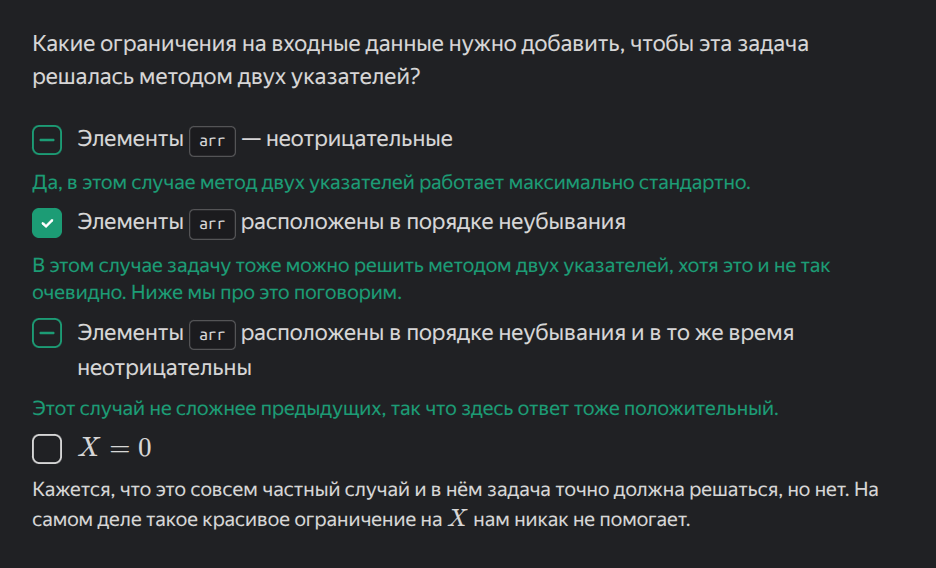


In [35]:
def subarray_sum_MY(arr, x):
    left, right = 0, 0
    while right < len(arr) and left <= right:
        temp_sum = sum(arr[left:right])
        if temp_sum == x:
            return True
        elif temp_sum < x:
            right += 1
        else:
            left += 1
    return False

def subarray_sum_1(non_negative_arr, target):
    right, current_sum = 0, 0
    for left in range(len(non_negative_arr)):
        # пересчитываем сумму
        if left > 0:
            current_sum -= non_negative_arr[left - 1]

        # при необходимости двигаем правую границу
        while right < len(non_negative_arr) and current_sum < target:
            current_sum += non_negative_arr[right]
            right += 1

        if current_sum == target:
            return True

    return False


def subarray_sum(arr, target):
    prefix_sums = set([0])
    temp_sum = 0
    for i in range(len(arr)):
        temp_sum += arr[i]
        if temp_sum - target in prefix_sums:
            return True
        prefix_sums.add(temp_sum)
    return False

assert subarray_sum([2, 5, 5, 19], 10) == True
assert subarray_sum([2, 5, 5, 19], 12) == True
assert subarray_sum([2, 5, 5, 19], 13) == False